<a href="https://colab.research.google.com/github/iannickgagnon/notebooks/blob/main/eli_health/roi_horizontal_filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Create list of file names

In [14]:
filenames: list[str] = [f"{i}.jpg" for i in range(1, 5)]

for i, filename in enumerate(filenames):
  print(f"Image no.{i + 1}: {filename}")

Image no.1: 1.jpg
Image no.2: 2.jpg
Image no.3: 3.jpg
Image no.4: 4.jpg


# Store and show raw and median filtered images

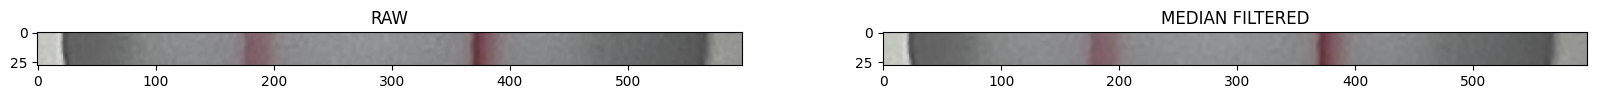

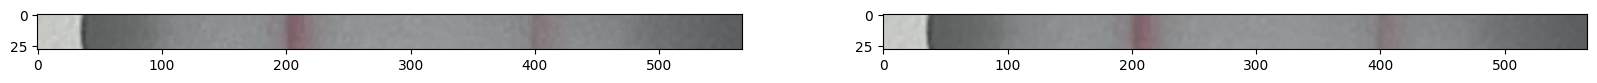

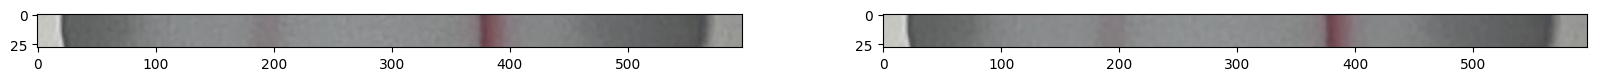

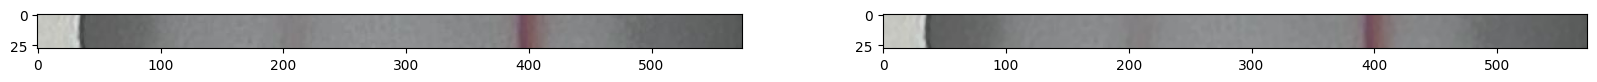

In [76]:
# NOTE: Without plt.figure(), plt.imshow() will keep drawing on the current figure

raw_images: dict[str, np.ndarray] = {}
raw_histograms: dict[str, np.ndarray] = {}

median_filtered_images: dict[str, np.ndarray] = {}
median_filtered_histograms: dict[str, np.ndarray] = {}

for i, filename in enumerate(filenames):

  # Load and transform
  img = plt.imread(filename).astype(np.int32)

  img_median_filtered = median_filter(img, size=(3,3,1))

  # Store
  raw_images[filename] = img
  raw_histogram = np.sum(img[:, :, 1], axis=0)
  raw_histogram_inv = np.abs(raw_histogram - np.max(raw_histogram))
  raw_histograms[filename] = raw_histogram_inv

  median_filtered_images[filename] = img_median_filtered
  median_filtered_histogram = np.sum(img_median_filtered[:, :, 1], axis=0)
  median_filtered_histogram_inv = np.abs(median_filtered_histogram - np.max(median_filtered_histogram))
  median_filtered_histograms[filename] = median_filtered_histogram_inv

  # Show side by side
  _, ax = plt.subplots(ncols=2, figsize=(20, 20))

  # Show
  ax[0].imshow(img)
  ax[1].imshow(img_median_filtered)

  # Title only on the two frist ones
  if i == 0:
    ax[0].set_title(f"RAW")
    ax[1].set_title(f"MEDIAN FILTERED")

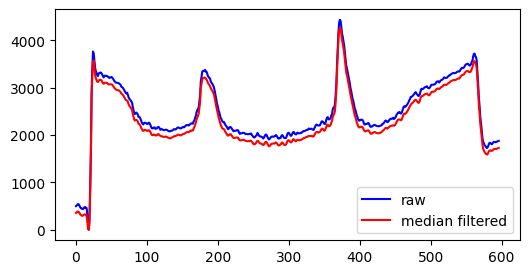

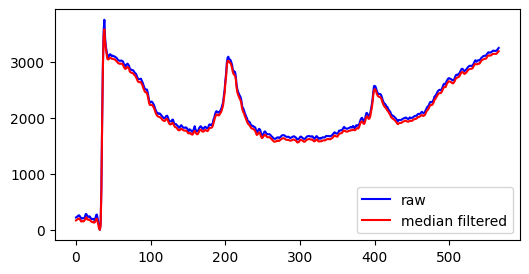

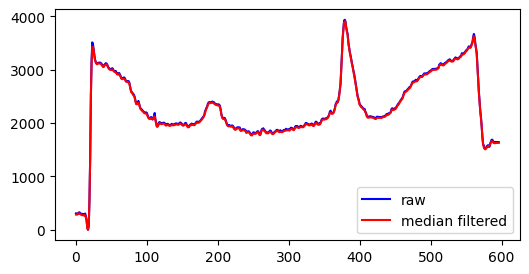

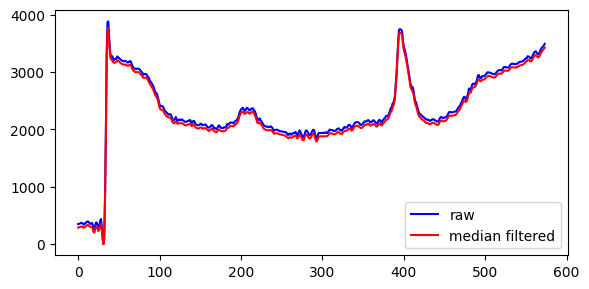

In [91]:
for i, filename in enumerate(filenames):

  plt.figure(figsize=(6,3))

  # Show
  plt.plot(raw_histograms[filename], color='b', label='raw')
  plt.plot(median_filtered_histograms[filename], color='r', label='median filtered')

  # Add legend
  plt.legend(loc='lower right')

plt.tight_layout()

# Horizontal derivative

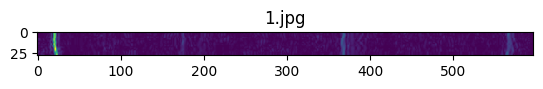

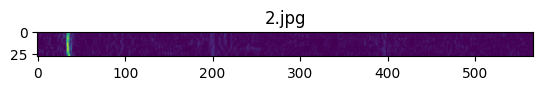

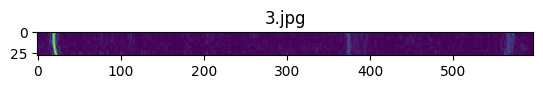

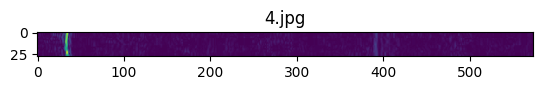

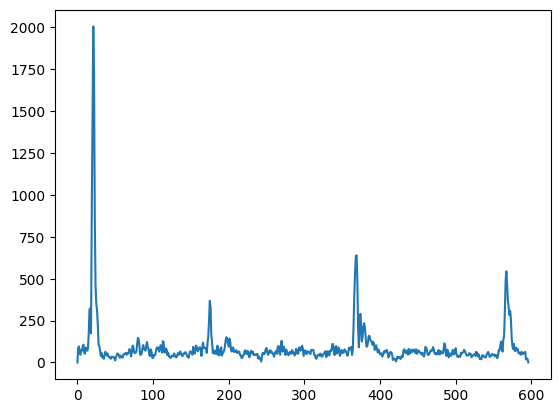

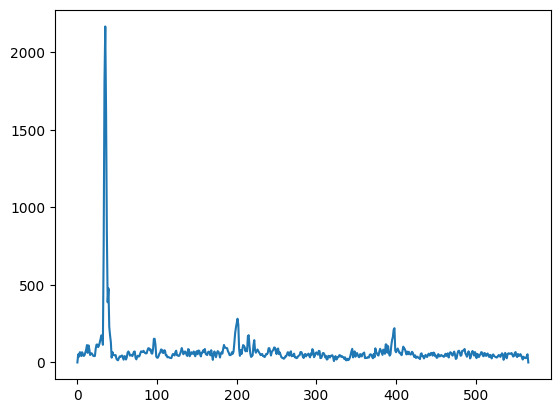

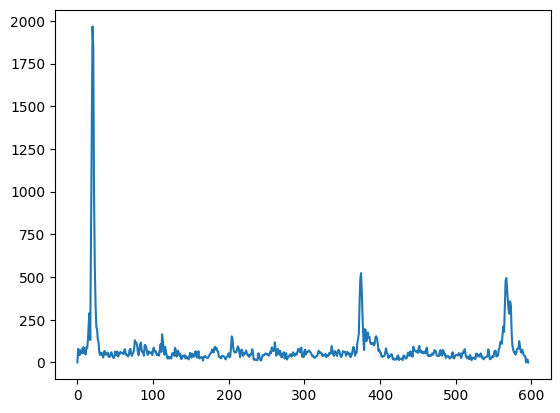

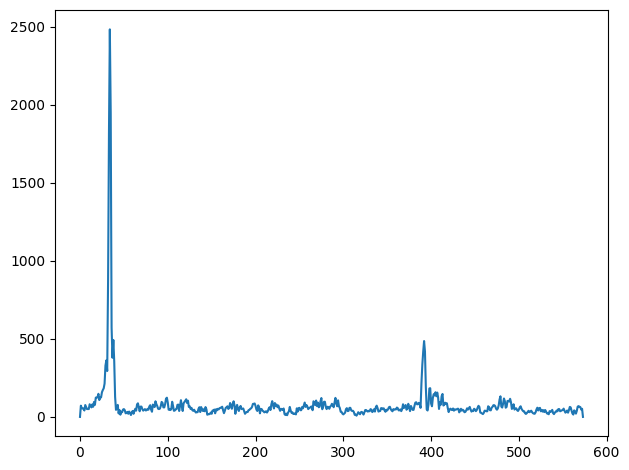

In [98]:

raw_horizontal_derivatives_images: dict[str, np.ndarray] = {}
raw_horizontal_derivatives_histograms: dict[str, np.ndarray] = {}

for filename in filenames:

  # Load image
  img = raw_images[filename]

  # New figure
  plt.figure()

  # If RGB, convert to grayscale
  if img.ndim == 3:
      gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
  else:
      gray = img

  # Horizontal derivative
  kernel = np.array([[-1, 0, 1]], dtype=np.float32)
  response = np.abs(cv2.filter2D(gray.astype(np.float32), -1, kernel))
  histogram = np.sum(np.abs(response), axis=0)

  # Store
  raw_horizontal_derivatives_images[filename] = response
  raw_horizontal_derivatives_histograms[filename] = histogram

  # Show just the images
  plt.imshow(response)
  plt.title(filename)

# Show horizontal derivatives histograms
for filename in filenames:
  plt.figure()
  plt.plot(raw_horizontal_derivatives_histograms[filename])

plt.tight_layout()

# Sobel in x

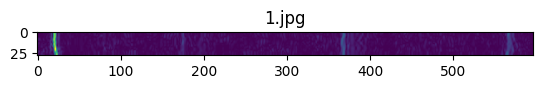

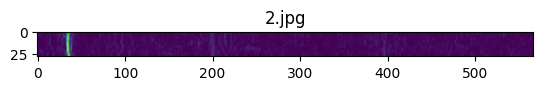

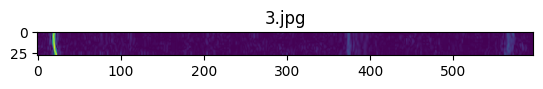

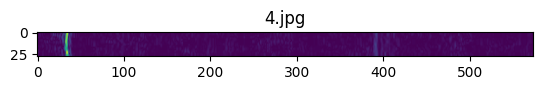

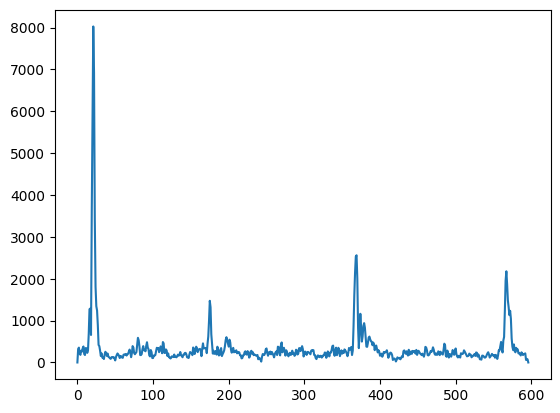

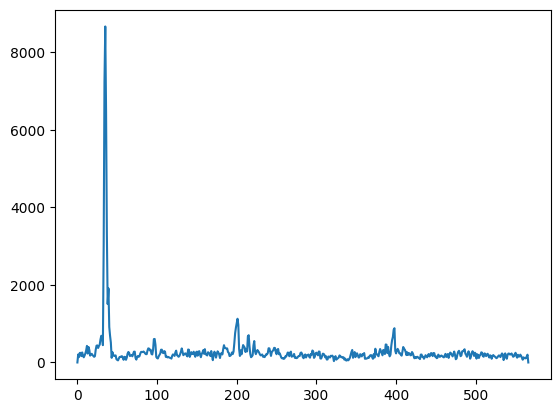

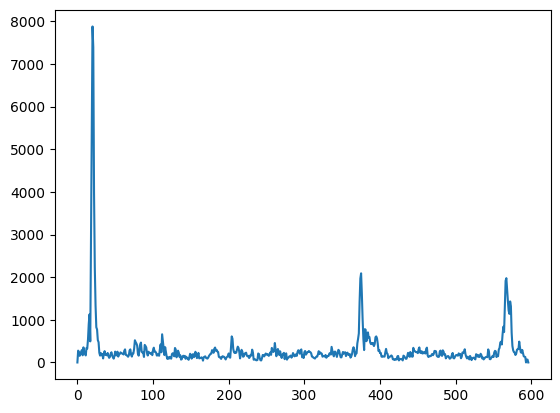

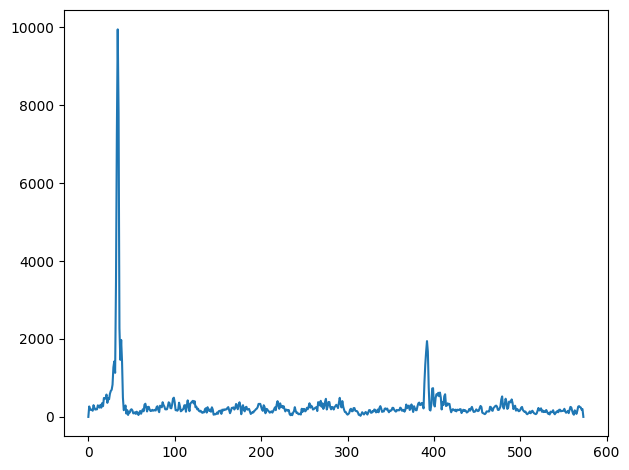

In [96]:

sobel_in_x_images: dict[str, np.ndarray] = {}
sobel_in_x_histograms: dict[str, np.ndarray] = {}

for filename in filenames:

  # Load image
  img = raw_images[filename]

  # New figure
  plt.figure()

  # If RGB, convert to grayscale
  if img.ndim == 3:
      gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
  else:
      gray = img

  # Horizontal derivative
  grad_x = np.abs(cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3))
  histogram = np.sum(grad_x, axis=0)

  # Store
  sobel_in_x_images[filename] = response
  sobel_in_x_histograms[filename] = histogram

  # Show just the images
  plt.imshow(grad_x)
  plt.title(filename)

# Show horizontal derivatives histograms
for filename in filenames:
  plt.figure()
  plt.plot(sobel_in_x_histograms[filename])

plt.tight_layout()

In [ ]:
sobel_in_x_images: dict[str, np.ndarray] = {}
sobel_in_x_histograms: dict[str, np.ndarray] = {}

for filename in filenames:

  # Load image
  img = raw_images[filename]

  # New figure
  plt.figure()

  # If RGB, convert to grayscale
  if img.ndim == 3:
      gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
  else:
      gray = img

  # Horizontal derivative
  grad_x = np.abs(cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3))
  histogram = np.sum(grad_x, axis=0)

  # Store
  sobel_in_x_images[filename] = response
  sobel_in_x_histograms[filename] = histogram

  # Show just the images
  plt.imshow(grad_x)
  plt.title(filename)

# Show horizontal derivatives histograms
for filename in filenames:
  plt.figure()
  plt.plot(sobel_in_x_histograms[filename])

plt.tight_layout()